# Provider Asset Market Data Quality Check

Tests for gaps in minutely market data over the past 14 days for every (provider, from_asset, to_asset) pair currently registered in `provider_asset_group_member`. Expectation: every minute in the window should have a row for every pair.

In [1]:
import datetime as dt
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, select

import mc_postgres_db.models as models

load_dotenv()

POSTGRES_URL = os.getenv("POSTGRES_URL")
engine = create_engine(POSTGRES_URL)

In [2]:
lookback_days = 14

end_time = dt.datetime.combine(dt.datetime.utcnow().date(), dt.time.min)
start_time = end_time - dt.timedelta(days=lookback_days)

expected_minutes = lookback_days * 24 * 60
expected_index = pd.date_range(
    start=start_time, end=end_time - dt.timedelta(minutes=1), freq="1min"
)

print(
    f"Window: {start_time:%Y-%m-%d %H:%M} -> {end_time:%Y-%m-%d %H:%M} UTC "
    f"({expected_minutes:,} minutes expected per pair)"
)

Window: 2026-04-17 00:00 -> 2026-05-01 00:00 UTC (20,160 minutes expected per pair)


/var/folders/y6/7bjblwtj5wsc083gp32qxj8c0000gn/T/ipykernel_62713/3326719047.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time = dt.datetime.combine(dt.datetime.utcnow().date(), dt.time.min)


## Load registered pairs
Pulls the (provider_id, from_asset_id, to_asset_id) triples from `provider_asset_group_member`.

In [3]:
pairs_df = pd.read_sql(
    select(
        models.ProviderAssetGroupMember.provider_id,
        models.ProviderAssetGroupMember.from_asset_id,
        models.ProviderAssetGroupMember.to_asset_id,
    ).distinct(),
    engine,
)

asset_df = pd.read_sql(
    select(models.Asset.id, models.Asset.symbol, models.Asset.name),
    engine,
)
provider_df = pd.read_sql(
    select(models.Provider.id, models.Provider.name),
    engine,
)

asset_label = asset_df.set_index("id")["symbol"].fillna(asset_df.set_index("id")["name"])
provider_label = provider_df.set_index("id")["name"]

pairs_df["pair_label"] = (
    pairs_df["provider_id"].map(provider_label)
    + " | "
    + pairs_df["from_asset_id"].map(asset_label).astype(str)
    + "->"
    + pairs_df["to_asset_id"].map(asset_label).astype(str)
)

print(f"{len(pairs_df)} unique pairs")
pairs_df.head()

172 unique pairs


,provider_id,from_asset_id,to_asset_id,pair_label
0,1,19,82,Kraken | USDC->VIRTUAL
1,1,19,51,Kraken | USDC->TRUMP
2,1,19,77,Kraken | USDC->FARTCOIN
3,1,2,76,Kraken | USD->PAXG
4,1,18,77,Kraken | USDT->FARTCOIN


## Load market data for window
Restricts to pairs in `provider_asset_group_member` so we don't pull unrelated rows.

In [4]:
pair_keys = list(
    pairs_df[["provider_id", "from_asset_id", "to_asset_id"]].itertuples(
        index=False, name=None
    )
)

market_query = (
    select(
        models.ProviderAssetMarket.timestamp,
        models.ProviderAssetMarket.provider_id,
        models.ProviderAssetMarket.from_asset_id,
        models.ProviderAssetMarket.to_asset_id,
        models.ProviderAssetMarket.close,
    )
    .where(
        models.ProviderAssetMarket.timestamp >= start_time,
        models.ProviderAssetMarket.timestamp < end_time,
        models.ProviderAssetMarket.provider_id.in_(
            pairs_df["provider_id"].unique().tolist()
        ),
    )
)

market_df = pd.read_sql(market_query, engine)
market_df["timestamp"] = pd.to_datetime(market_df["timestamp"]).dt.floor("1min")

market_df = market_df.merge(
    pairs_df[["provider_id", "from_asset_id", "to_asset_id", "pair_label"]],
    on=["provider_id", "from_asset_id", "to_asset_id"],
    how="inner",
)

print(f"Loaded {len(market_df):,} rows across {market_df['pair_label'].nunique()} pairs")

Loaded 3,353,710 rows across 172 pairs


## Per-pair coverage summary

In [5]:
observed = (
    market_df.groupby("pair_label")["timestamp"]
    .nunique()
    .rename("observed_minutes")
    .reindex(pairs_df["pair_label"], fill_value=0)
)

summary = pd.DataFrame({"observed_minutes": observed})
summary["expected_minutes"] = expected_minutes
summary["missing_minutes"] = summary["expected_minutes"] - summary["observed_minutes"]
summary["coverage"] = summary["observed_minutes"] / summary["expected_minutes"]
summary = summary.sort_values("coverage")

print(
    f"Pairs at 100% coverage: {(summary['coverage'] >= 1.0).sum()} / {len(summary)}"
)
summary.head(20)

Pairs at 100% coverage: 124 / 172


,observed_minutes,expected_minutes,missing_minutes,coverage
pair_label,,,,
Kraken | ETH->ETC,17788,20160,2372,0.882341
Kraken | BTC->ETC,17788,20160,2372,0.882341
Kraken | USD->USDC,17789,20160,2371,0.882391
Kraken | USDC->VIRTUAL,17789,20160,2371,0.882391
Kraken | USDC->DOGE,17789,20160,2371,0.882391
Kraken | USDT->BTC,17789,20160,2371,0.882391
Kraken | USD->TRX,17789,20160,2371,0.882391
Kraken | USDC->TRUMP,17789,20160,2371,0.882391
Kraken | USD->XMR,17789,20160,2371,0.882391


## Build pair x minute presence matrix
1 = row exists for that minute, 0 = gap.

In [6]:
presence = (
    market_df.assign(present=1)
    .pivot_table(
        index="pair_label",
        columns="timestamp",
        values="present",
        aggfunc="max",
        fill_value=0,
    )
    .reindex(index=pairs_df["pair_label"], columns=expected_index, fill_value=0)
    .astype(np.int8)
)

presence = presence.loc[summary.index]
presence.shape

(172, 20160)

## Heatmap: gaps per pair over time
Dark = data present, light = gap.

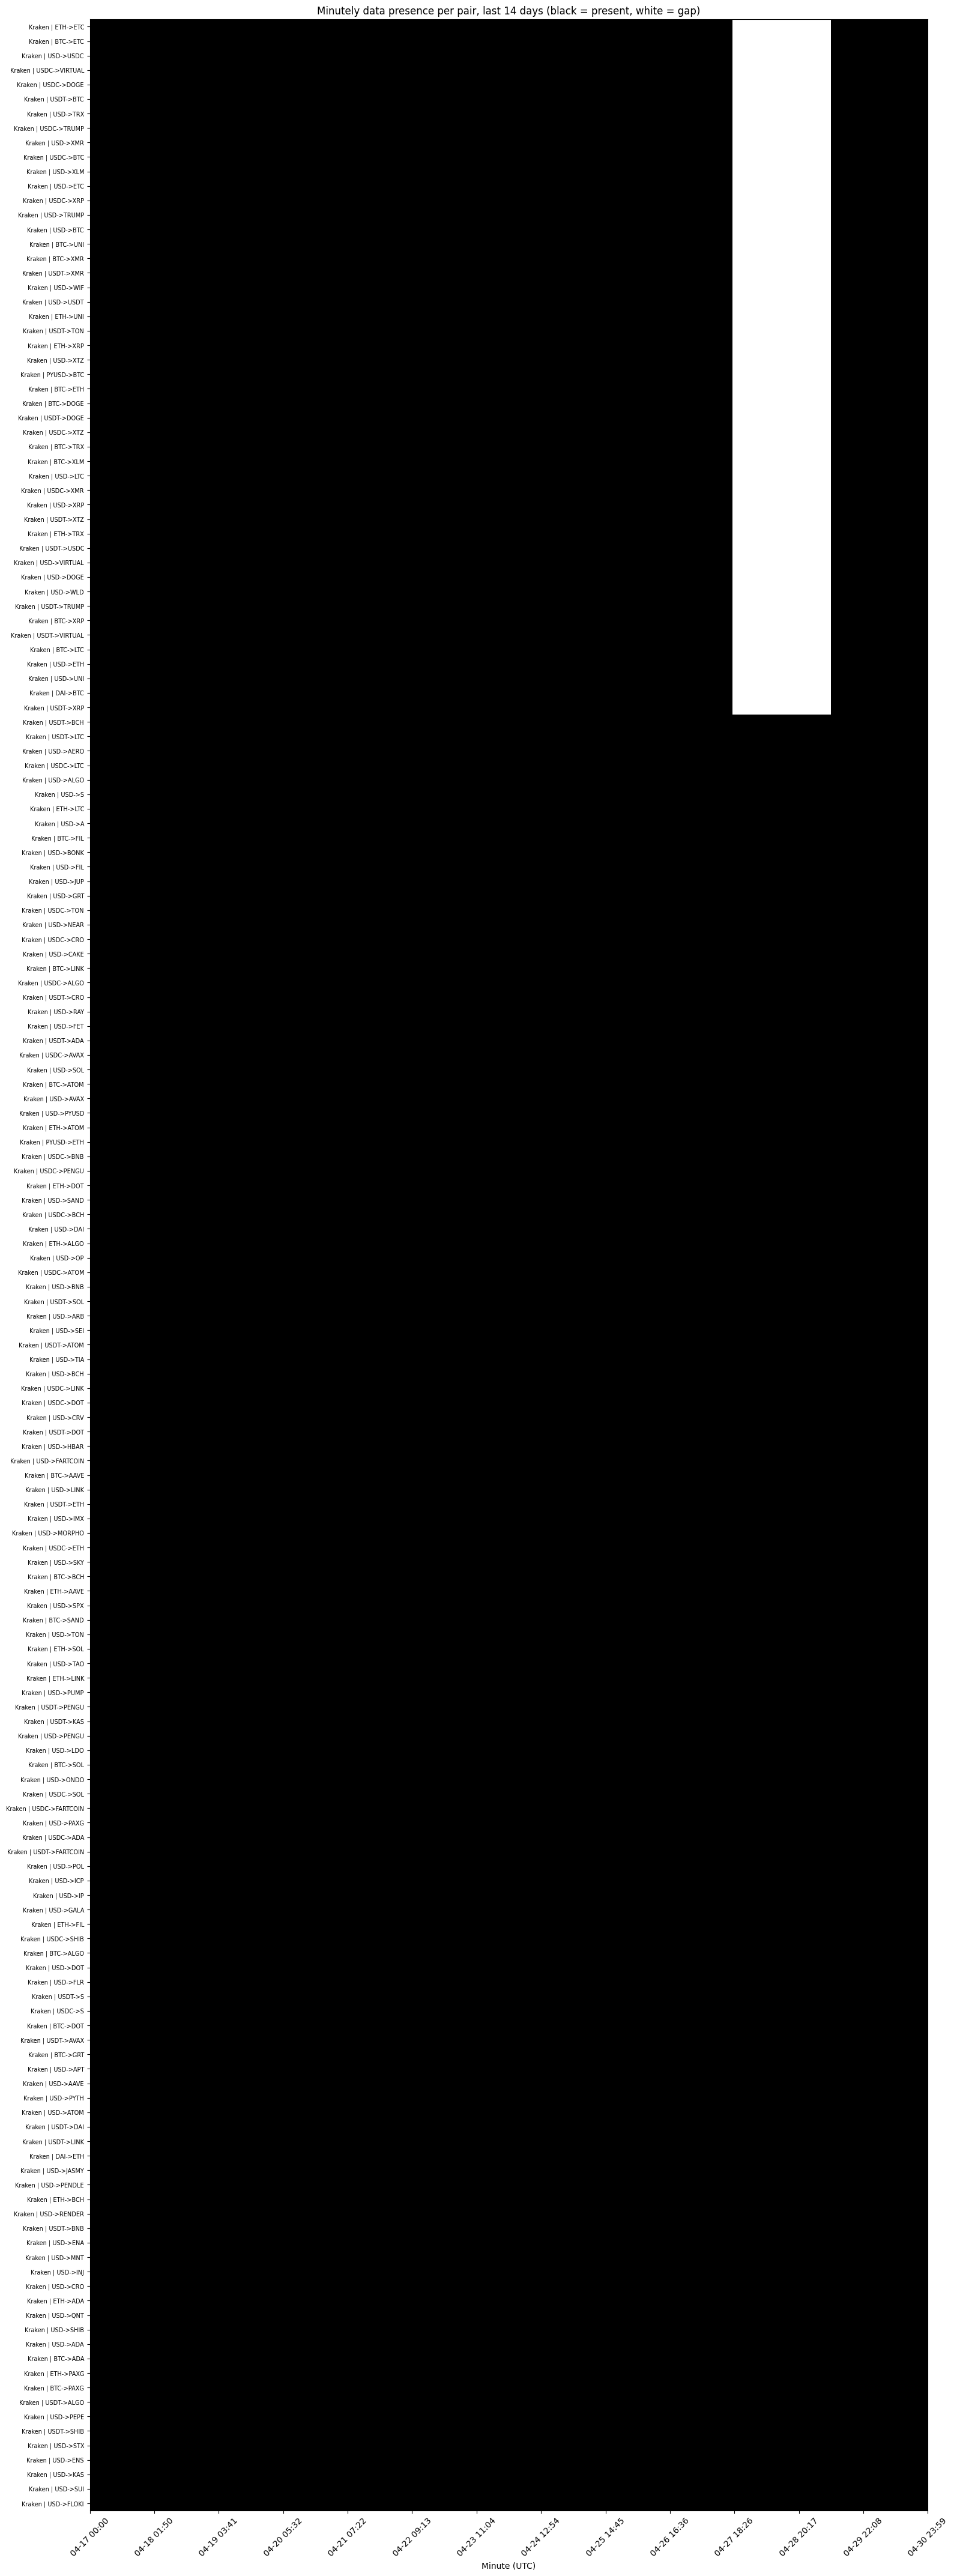

In [7]:
fig, ax = plt.subplots(figsize=(16, max(4, len(presence) * 0.25)))
ax.imshow(
    presence.values,
    aspect="auto",
    interpolation="nearest",
    cmap="Greys",
    vmin=0,
    vmax=1,
)

n_ticks = 14
tick_positions = np.linspace(0, len(expected_index) - 1, n_ticks).astype(int)
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    [expected_index[i].strftime("%m-%d %H:%M") for i in tick_positions], rotation=45
)
ax.set_yticks(range(len(presence)))
ax.set_yticklabels(presence.index, fontsize=7)
ax.set_xlabel("Minute (UTC)")
ax.set_title(
    f"Minutely data presence per pair, last {lookback_days} days "
    f"(black = present, white = gap)"
)
fig.tight_layout()
plt.show()

## Aggregate fill rate over time
Fraction of pairs that have a row for each minute. 1.0 means every pair reported.

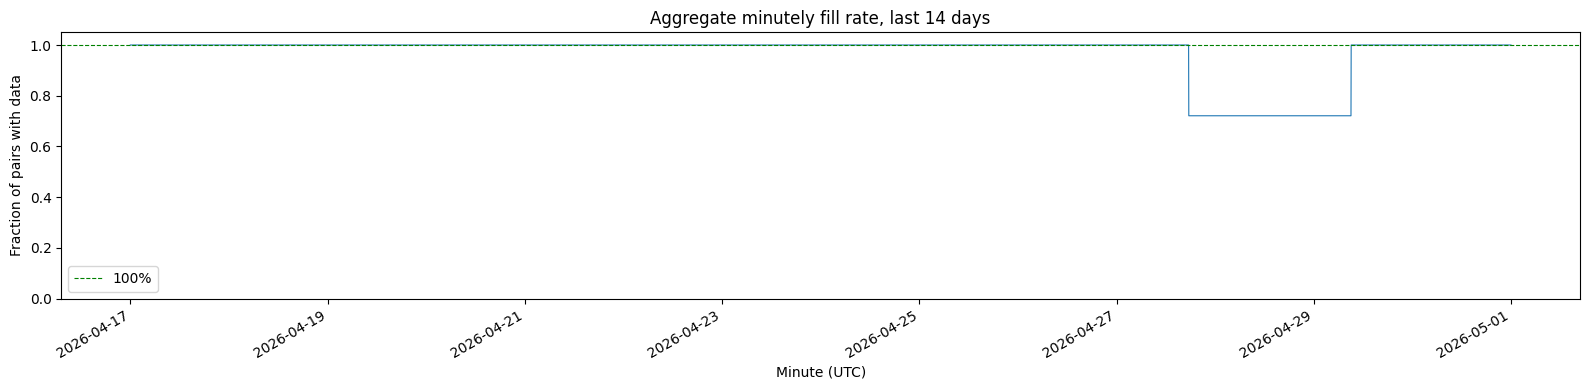

In [8]:
fill_rate = presence.mean(axis=0)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(fill_rate.index, fill_rate.values, linewidth=0.8)
ax.axhline(1.0, color="green", linestyle="--", linewidth=0.8, label="100%")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fraction of pairs with data")
ax.set_xlabel("Minute (UTC)")
ax.set_title(f"Aggregate minutely fill rate, last {lookback_days} days")
ax.legend(loc="lower left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Longest contiguous gap per pair

In [9]:
def longest_run_of_zeros(row: np.ndarray) -> int:
    longest = current = 0
    for v in row:
        if v == 0:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return longest


summary["longest_gap_minutes"] = [
    longest_run_of_zeros(presence.loc[label].values) for label in summary.index
]
summary.sort_values("longest_gap_minutes", ascending=False).head(20)

,observed_minutes,expected_minutes,missing_minutes,coverage,longest_gap_minutes
pair_label,,,,,
Kraken | ETH->ETC,17788,20160,2372,0.882341,2372
Kraken | BTC->ETC,17788,20160,2372,0.882341,2372
Kraken | USD->USDC,17789,20160,2371,0.882391,2371
Kraken | USDC->VIRTUAL,17789,20160,2371,0.882391,2371
Kraken | USDC->DOGE,17789,20160,2371,0.882391,2371
Kraken | USDT->BTC,17789,20160,2371,0.882391,2371
Kraken | USD->TRX,17789,20160,2371,0.882391,2371
Kraken | USDC->TRUMP,17789,20160,2371,0.882391,2371
Kraken | USD->XMR,17789,20160,2371,0.882391,2371
